In [1]:
import pywt
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import h5py

In [2]:
data_path = "../UCI/data"
FS = 125
WINDOW_SIZE = 1000

In [3]:
recordings = []

for part in range(1,5):

    file_path = f"{data_path}/Part_{part}.mat"

    f = h5py.File(file_path, "r")

    dataset = f[f"Part_{part}"]


    for i in range(dataset.shape[0]):

        recordings.append(
            (f, dataset[i,0])
        )


print("Total recordings:", len(recordings))

Total recordings: 12000


In [4]:
# Get the file handle and HDF5 reference
file_handle, recording_ref = recordings[0]

# Dereference the HDF5 reference
recording = file_handle[recording_ref]

print(type(recording))
print("Shape:", recording.shape)
print("Dtype:", recording.dtype)

<class 'h5py._hl.dataset.Dataset'>
Shape: (61000, 3)
Dtype: float64


In [5]:
def wavelet_denoise_db8(
    ppg,
    wavelet="db8",
    level=10
):

    ppg = np.asarray(
        ppg,
        dtype=np.float64
    )

    # -----------------------------------------
    # Check signal
    # -----------------------------------------

    if len(ppg) < 2:
        return None

    if not np.all(
        np.isfinite(ppg)
    ):
        return None

    # -----------------------------------------
    # DWT decomposition
    # -----------------------------------------

    coeffs = pywt.wavedec(
        ppg,
        wavelet=wavelet,
        level=level
    )

    # coeffs structure:
    #
    # [A10, D10, D9, ..., D2, D1]
    #
    # A10 = lowest-frequency approximation
    # D1  = highest-frequency detail

    # -----------------------------------------
    # Remove the lowest-frequency
    # approximation component
    #
    # This removes very slow baseline
    # variation.
    # -----------------------------------------

    coeffs[0] = np.zeros_like(
        coeffs[0]
    )

    # -----------------------------------------
    # Reconstruct signal
    # -----------------------------------------

    denoised = pywt.waverec(
        coeffs,
        wavelet=wavelet
    )

    # waverec can return slightly more samples
    # because of boundary handling.
    
    denoised = denoised[
        :len(ppg)
    ]

    return denoised.astype(
        np.float32
    )

In [6]:
def analyze_wavelet_denoising(
    ppg,
    denoised_ppg,
    fs=125,
    plot_seconds=30
):
    """
    Compare original and wavelet-denoised PPG.

    Parameters
    ----------
    ppg : array-like
        Original PPG signal.

    denoised_ppg : array-like
        Wavelet-denoised PPG signal.

    fs : int
        Sampling frequency in Hz.

    plot_seconds : int or float
        Duration of signal to show in the first plot.

    Returns
    -------
    results : dict
        Dictionary containing comparison statistics.
    """

    # ==================================================
    # Convert to numpy arrays
    # ==================================================

    ppg = np.asarray(ppg).squeeze()
    denoised_ppg = np.asarray(denoised_ppg).squeeze()


    # ==================================================
    # Check shapes
    # ==================================================

    if ppg.shape != denoised_ppg.shape:

        raise ValueError(
            f"Shape mismatch: "
            f"PPG {ppg.shape} vs "
            f"Denoised {denoised_ppg.shape}"
        )


    # ==================================================
    # Basic statistics
    # ==================================================

    original_mean = np.mean(ppg)
    original_std = np.std(ppg)
    original_min = np.min(ppg)
    original_max = np.max(ppg)

    denoised_mean = np.mean(denoised_ppg)
    denoised_std = np.std(denoised_ppg)
    denoised_min = np.min(denoised_ppg)
    denoised_max = np.max(denoised_ppg)


    # ==================================================
    # Removed component
    # ==================================================

    removed_component = (
        ppg - denoised_ppg
    )


    # ==================================================
    # Correlation
    # ==================================================

    correlation = np.corrcoef(
        ppg,
        denoised_ppg
    )[0, 1]


    # ==================================================
    # Residual statistics
    #
    # Remove mean first so that the DC/baseline
    # difference does not dominate the residual.
    # ==================================================

    ppg_centered = (
        ppg - original_mean
    )

    denoised_centered = (
        denoised_ppg - denoised_mean
    )

    residual = (
        ppg_centered -
        denoised_centered
    )

    residual_std = np.std(
        residual
    )

    residual_ratio = (
        residual_std /
        original_std
    )


    # ==================================================
    # Print results
    # ==================================================

    print("=" * 50)
    print("WAVELET DENOISING ANALYSIS")
    print("=" * 50)

    print("\nShape:")
    print("Original shape :", ppg.shape)
    print("Denoised shape :", denoised_ppg.shape)

    print("\nOriginal:")
    print(
        f"Mean : {original_mean:.6f}"
    )
    print(
        f"Std  : {original_std:.6f}"
    )
    print(
        f"Min  : {original_min:.6f}"
    )
    print(
        f"Max  : {original_max:.6f}"
    )

    print("\nDenoised:")
    print(
        f"Mean : {denoised_mean:.6f}"
    )
    print(
        f"Std  : {denoised_std:.6f}"
    )
    print(
        f"Min  : {denoised_min:.6f}"
    )
    print(
        f"Max  : {denoised_max:.6f}"
    )

    print("\nSimilarity:")
    print(
        f"Correlation : {correlation:.5f}"
    )

    print("\nResidual:")
    print(
        f"Residual std : {residual_std:.6f}"
    )
    print(
        f"Residual / signal std : "
        f"{residual_ratio * 100:.3f}%"
    )


    # ==================================================
    # Plot 1: Original vs denoised
    # ==================================================

    N = min(
        int(plot_seconds * fs),
        len(ppg)
    )

    plt.figure(
        figsize=(15, 5)
    )

    plt.plot(
        ppg[:N],
        label="Original PPG",
        alpha=0.7
    )

    plt.plot(
        denoised_ppg[:N],
        label="Denoised PPG",
        linewidth=1.5
    )

    plt.xlabel(
        "Sample"
    )

    plt.ylabel(
        "Amplitude"
    )

    plt.title(
        "Original vs db8 Wavelet-Denoised PPG"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.show()


    # ==================================================
    # Plot 2: Removed component
    # ==================================================

    plt.figure(
        figsize=(15, 4)
    )

    plt.plot(
        removed_component
    )

    plt.xlabel(
        "Sample"
    )

    plt.ylabel(
        "Amplitude"
    )

    plt.title(
        "Component Removed by Wavelet Denoising"
    )

    plt.grid(
        alpha=0.3
    )

    plt.show()


    # ==================================================
    # Plot 3: Centered residual
    # ==================================================

    plt.figure(
        figsize=(15, 4)
    )

    plt.plot(
        residual
    )

    plt.xlabel(
        "Sample"
    )

    plt.ylabel(
        "Amplitude"
    )

    plt.title(
        "Wavelet Residual After Removing DC Offset"
    )

    plt.grid(
        alpha=0.3
    )

    plt.show()


    # ==================================================
    # Return results
    # ==================================================

    results = {

        "original_mean":
            original_mean,

        "original_std":
            original_std,

        "original_min":
            original_min,

        "original_max":
            original_max,

        "denoised_mean":
            denoised_mean,

        "denoised_std":
            denoised_std,

        "denoised_min":
            denoised_min,

        "denoised_max":
            denoised_max,

        "correlation":
            correlation,

        "residual_std":
            residual_std,

        "residual_ratio":
            residual_ratio
    }

    return results

In [7]:
def plot_dwt_levels(ppg, wavelet="db8", level=10, fs=125):
    """
    Decomposes a PPG signal using DWT and plots every level
    (A_level, D_level, ..., D1) as stacked subplots, so you can
    visually inspect which layer holds baseline drift, which
    holds the pulse waveform, and which is just noise.
    """
 
    ppg = np.asarray(ppg, dtype=np.float64)
 
    coeffs = pywt.wavedec(ppg, wavelet=wavelet, level=level)
    # coeffs = [A_level, D_level, D_(level-1), ..., D1]
 
    labels = [f"A{level}"] + [f"D{j}" for j in range(level, 0, -1)]
 
    # approximate frequency band each layer represents (Hz)
    bands = []
    bands.append((0, fs / 2**(level + 1)))  # A_level band
    for j in range(level, 0, -1):
        low = fs / 2**(j + 1)
        high = fs / 2**j
        bands.append((low, high))
 
    n_plots = len(coeffs) + 1
    fig, axes = plt.subplots(n_plots, 1, figsize=(12, 2 * n_plots), sharex=False)
 
    # original signal on top
    axes[0].plot(ppg, color="black", linewidth=0.8)
    axes[0].set_title("Original PPG signal")
 
    for ax, c, label, (lo, hi) in zip(axes[1:], coeffs, labels, bands):
        ax.plot(c, linewidth=0.8)
        ax.set_title(f"{label}  |  ~{lo:.3f}-{hi:.3f} Hz  |  n={len(c)}")
 
    plt.tight_layout()
    plt.savefig("dwt_levels.png", dpi=150)
    plt.show()
 
    return coeffs
 

In [8]:
ppg = recording[:, 0]
plot_dwt_levels(ppg, wavelet="db8", level=8, fs=fs)

NameError: name 'fs' is not defined

WAVELET DENOISING ANALYSIS

Shape:
Original shape : (61000,)
Denoised shape : (61000,)

Original:
Mean : 1.839741
Std  : 0.631976
Min  : 0.000000
Max  : 4.001955

Denoised:
Mean : 0.000911
Std  : 0.630671
Min  : -2.100419
Max  : 2.122572

Similarity:
Correlation : 0.99780

Residual:
Residual std : 0.041892
Residual / signal std : 6.629%


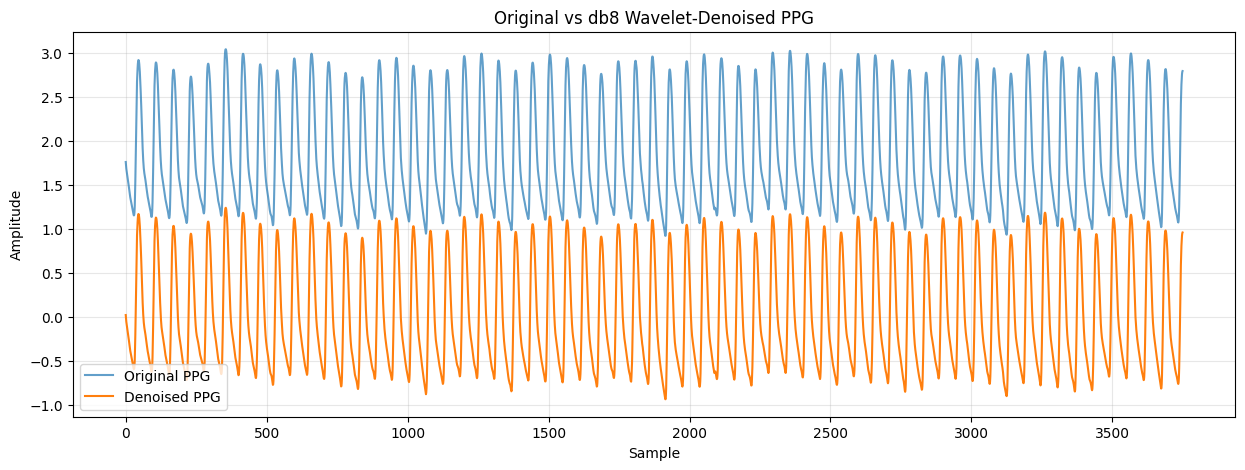

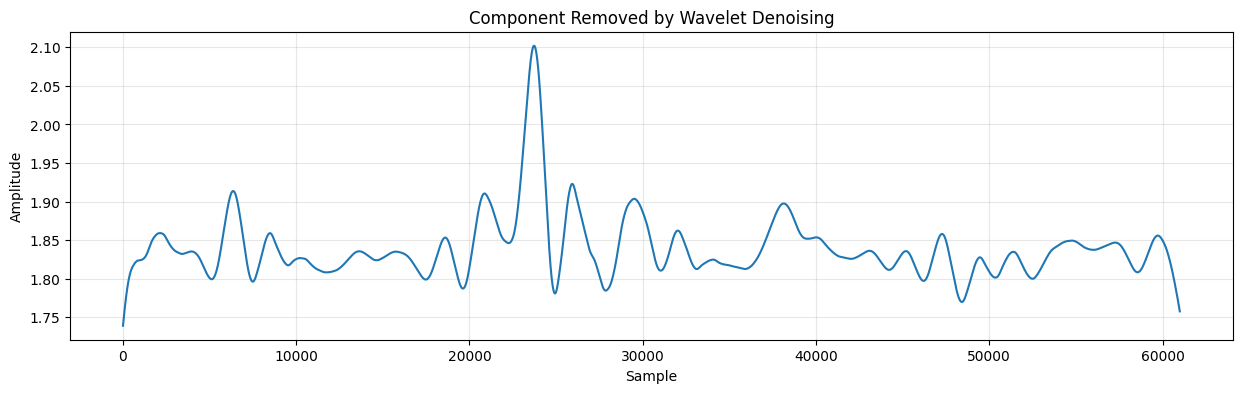

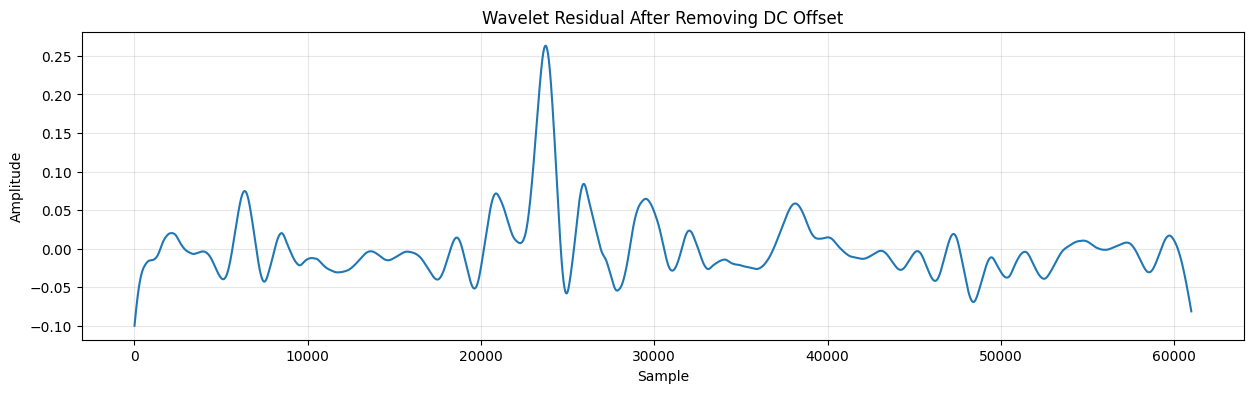

In [ ]:
ppg = recording[:, 0]

denoised_ppg = wavelet_denoise_db8(
    ppg,
    wavelet="db8",
    level=10
)

results = analyze_wavelet_denoising(
    ppg,
    denoised_ppg,
    fs=125,
    plot_seconds=30
)

In [ ]:
ppg = recording[:, 0]

denoised_ppg = wavelet_denoise_db8(
    ppg,
    wavelet="db8",
    level=9
)

WAVELET DENOISING ANALYSIS

Shape:
Original shape : (61000,)
Denoised shape : (61000,)

Original:
Mean : 1.839741
Std  : 0.631976
Min  : 0.000000
Max  : 4.001955

Denoised:
Mean : 0.000474
Std  : 0.629721
Min  : -2.082338
Max  : 2.095692

Similarity:
Correlation : 0.99629

Residual:
Residual std : 0.054389
Residual / signal std : 8.606%


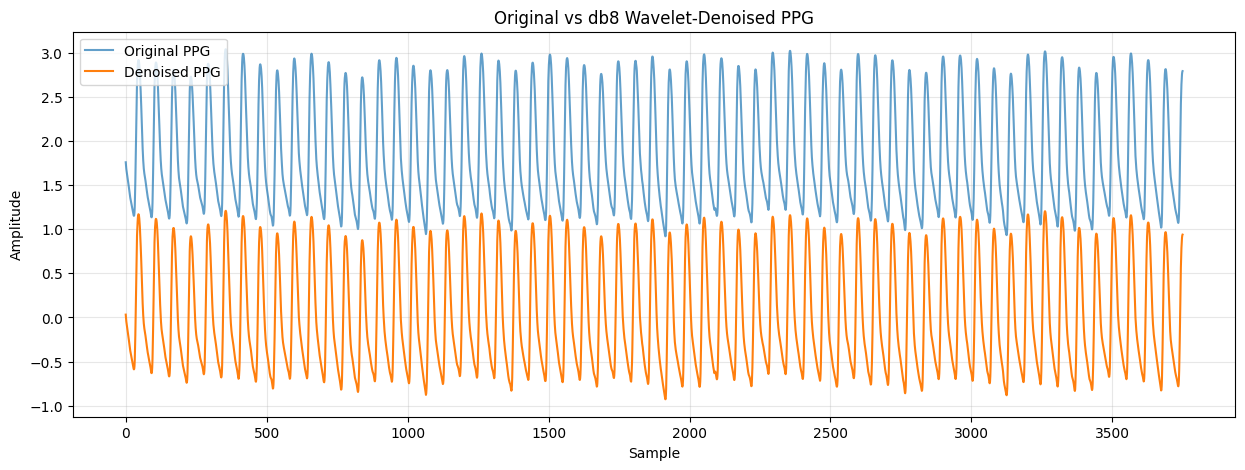

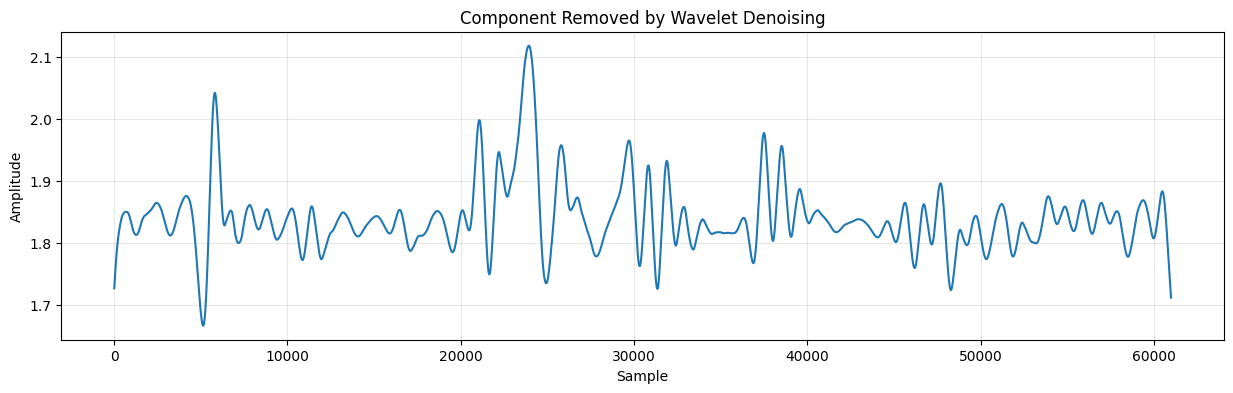

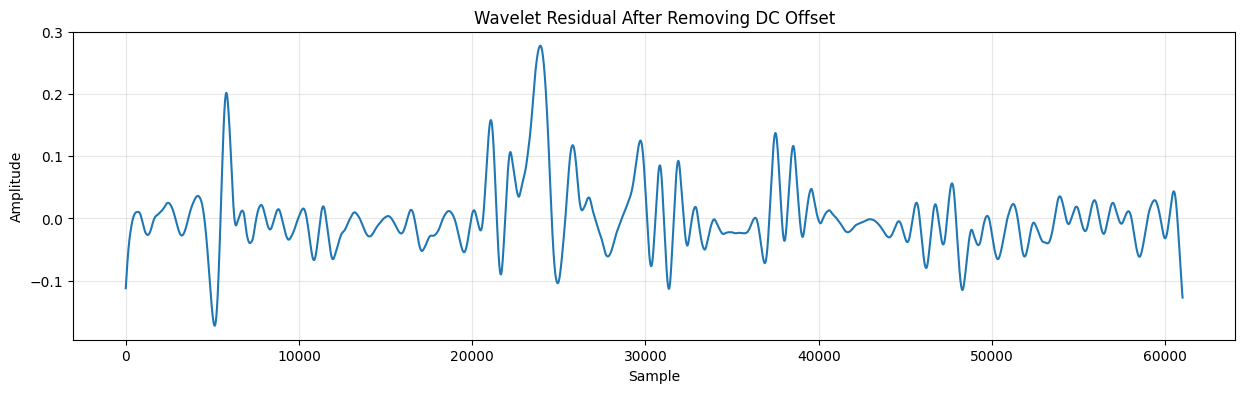

In [ ]:
results = analyze_wavelet_denoising(
    ppg,
    denoised_ppg,
    fs=125,
    plot_seconds=30
)

WAVELET DENOISING ANALYSIS

Shape:
Original shape : (61000,)
Denoised shape : (61000,)

Original:
Mean : 1.839741
Std  : 0.631976
Min  : 0.000000
Max  : 4.001955

Denoised:
Mean : 0.000281
Std  : 0.625627
Min  : -1.868762
Max  : 2.070604

Similarity:
Correlation : 0.98985

Residual:
Residual std : 0.089820
Residual / signal std : 14.213%


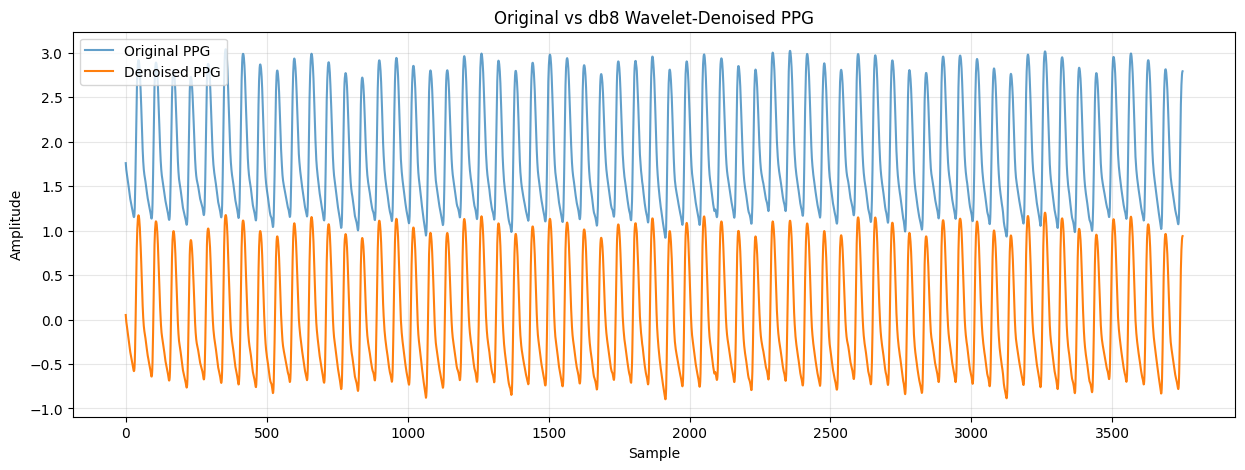

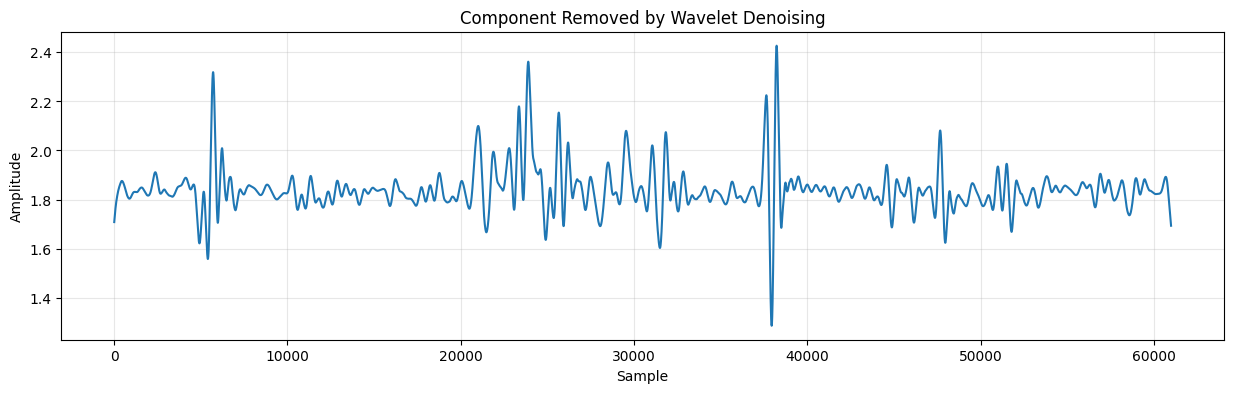

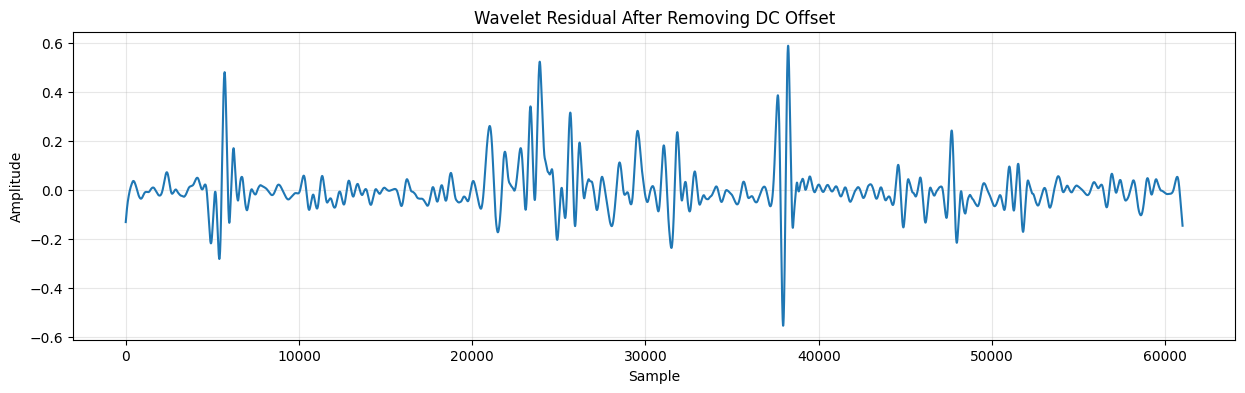

In [ ]:
ppg = recording[:, 0]

denoised_ppg = wavelet_denoise_db8(
    ppg,
    wavelet="db8",
    level=8
)

results = analyze_wavelet_denoising(
    ppg,
    denoised_ppg,
    fs=125,
    plot_seconds=30
)

WAVELET DENOISING ANALYSIS

Shape:
Original shape : (61000,)
Denoised shape : (61000,)

Original:
Mean : 1.839741
Std  : 0.631976
Min  : 0.000000
Max  : 4.001955

Denoised:
Mean : 0.000127
Std  : 0.619962
Min  : -1.784616
Max  : 2.013233

Similarity:
Correlation : 0.98095

Residual:
Residual std : 0.122757
Residual / signal std : 19.424%


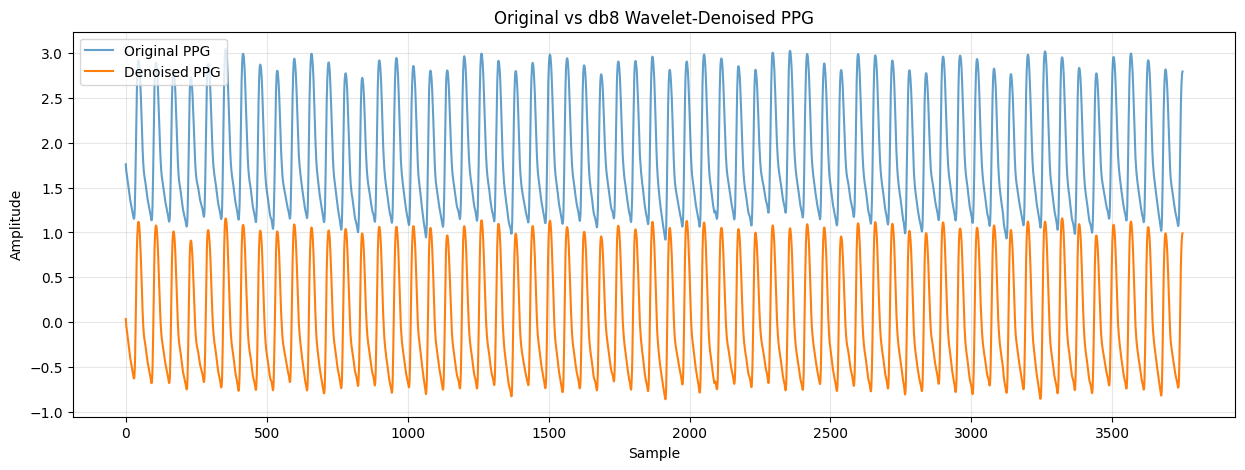

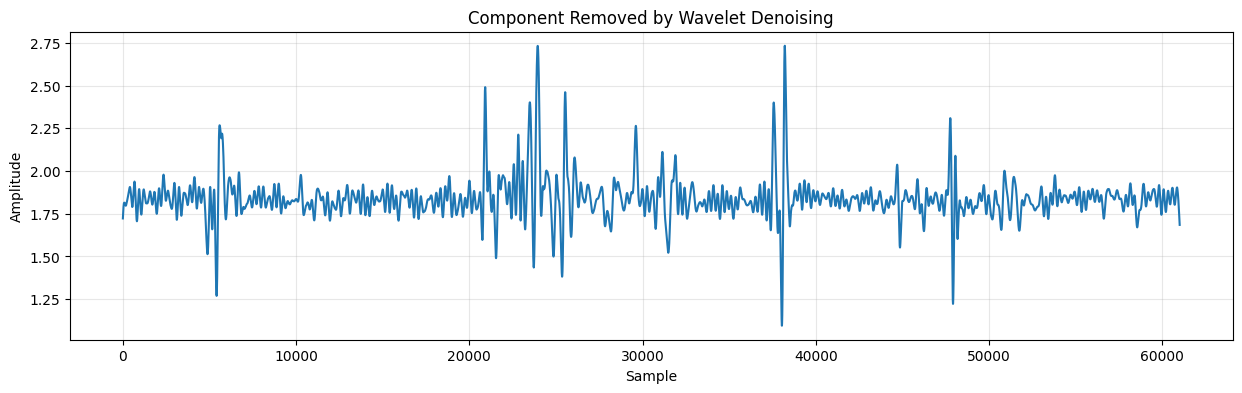

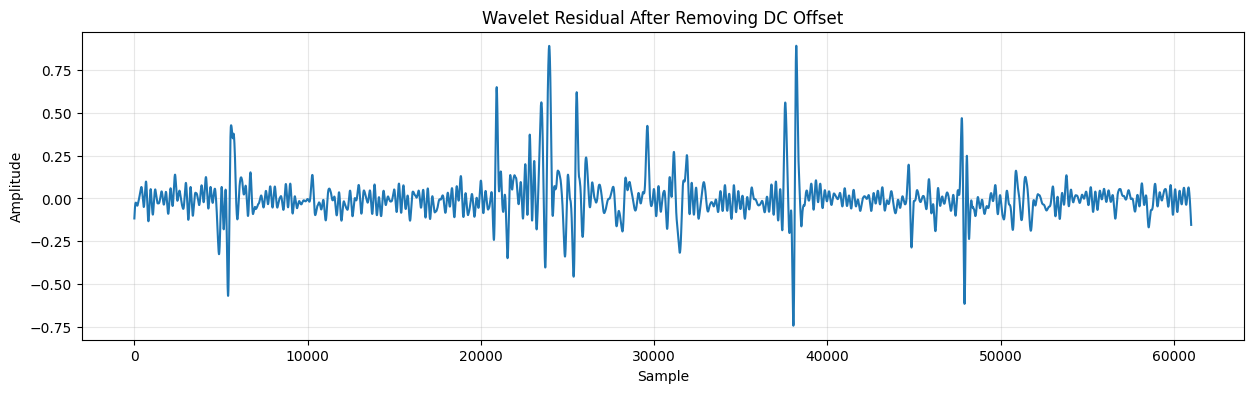

In [ ]:
ppg = recording[:, 0]

denoised_ppg = wavelet_denoise_db8(
    ppg,
    wavelet="db8",
    level=7
)

results = analyze_wavelet_denoising(
    ppg,
    denoised_ppg,
    fs=125,
    plot_seconds=30
)

WAVELET DENOISING ANALYSIS

Shape:
Original shape : (61000,)
Denoised shape : (61000,)

Original:
Mean : 1.839741
Std  : 0.631976
Min  : 0.000000
Max  : 4.001955

Denoised:
Mean : 0.000073
Std  : 0.612777
Min  : -1.567924
Max  : 1.944631

Similarity:
Correlation : 0.96957

Residual:
Residual std : 0.154724
Residual / signal std : 24.483%


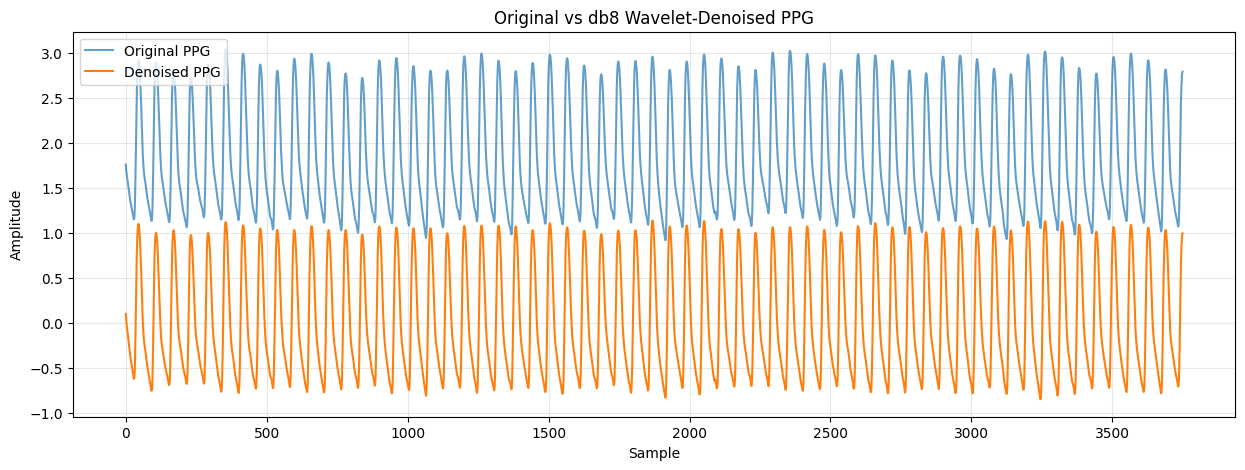

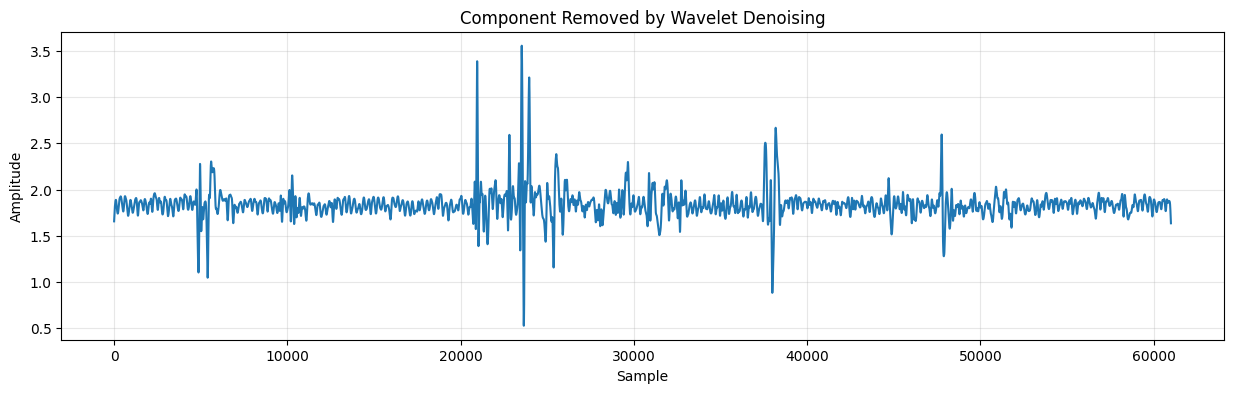

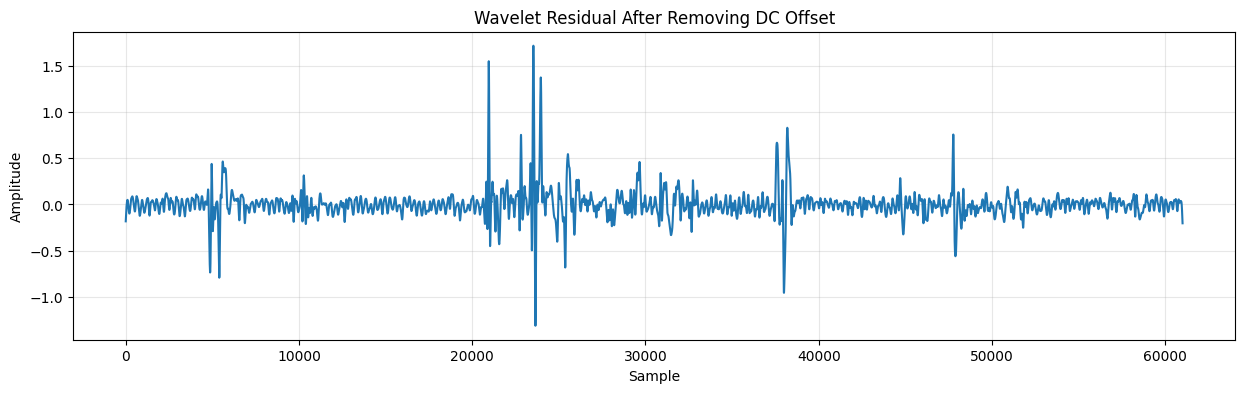

In [ ]:
ppg = recording[:, 0]

denoised_ppg = wavelet_denoise_db8(
    ppg,
    wavelet="db8",
    level=6
)

results = analyze_wavelet_denoising(
    ppg,
    denoised_ppg,
    fs=125,
    plot_seconds=30
)

In [ ]:
from scipy.signal import find_peaks

peaks_original, _ = find_peaks(
    ppg,
    distance=50
)

peaks_denoised, _ = find_peaks(
    denoised_ppg,
    distance=50
)

print(
    "Original peaks:",
    len(peaks_original)
)

print(
    "Denoised peaks:",
    len(peaks_denoised)
)

Original peaks: 994
Denoised peaks: 993


In [ ]:
noise = ppg - denoised_ppg

print("Noise mean:", np.mean(noise))
print("Noise std :", np.std(noise))

print(
    "Noise / signal std ratio:",
    np.std(noise) / np.std(ppg)
)

Noise mean: 1.8388295957764518
Noise std : 0.04189219875657301
Noise / signal std ratio: 0.0662876093331056


In [ ]:
ppg_centered = ppg - np.mean(ppg)

denoised_centered = (
    denoised_ppg - np.mean(denoised_ppg)
)

residual = (
    ppg_centered - denoised_centered
)

print("Residual mean:", np.mean(residual))
print("Residual std :", np.std(residual))

print(
    "Residual / signal std ratio:",
    np.std(residual) / np.std(ppg_centered)
)

Residual mean: 4.9537345084965385e-09
Residual std : 0.041892198612938185
Residual / signal std ratio: 0.06628760910582679


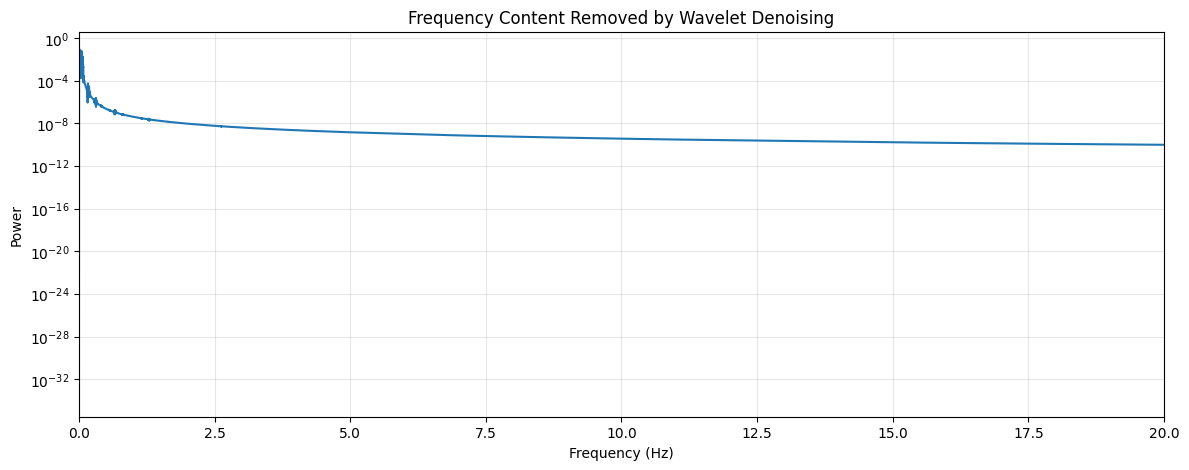

In [ ]:
from scipy.signal import periodogram

fs = 125

f, P = periodogram(
    residual,
    fs=fs
)

plt.figure(figsize=(14, 5))

plt.semilogy(
    f,
    P
)

plt.xlim(0, 20)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Frequency Content Removed by Wavelet Denoising")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
def extract_bp_from_abp(abp_window):

    # Detect systolic peaks
    peaks, _ = find_peaks(
        abp_window,
        distance=50,       # ~0.4 sec at 125 Hz
        prominence=5
    )


    # Need enough beats in the window
    if len(peaks) < 2:
        return None, None


    # SBP = pressure at systolic peaks
    sbp_values = abp_window[peaks]


    dbp_values = []


    # Find minimum pressure between consecutive systolic peaks
    for i in range(len(peaks)-1):

        beat_segment = abp_window[
            peaks[i]:peaks[i+1]
        ]

        if len(beat_segment) > 0:

            dbp_values.append(
                np.min(beat_segment)
            )


    if len(dbp_values) == 0:
        return None, None


    # Use median to reduce effect of noisy beats
    sbp = np.median(sbp_values)
    dbp = np.median(dbp_values)


    # Optional sanity check
    if sbp < 50 or sbp > 250:
        return None, None

    if dbp < 20 or dbp > 150:
        return None, None


    return sbp, dbp

In [ ]:
def process_recording(
    recording,
    window_size=1000,
    step_size=500,
    fs=125
):

    data = recording[:]

    # -----------------------------------------
    # Extract channels
    # -----------------------------------------

    ppg = data[:, 0]
    abp = data[:, 1]

    # -----------------------------------------
    # Recording-level PPG normalization
    # -----------------------------------------

    mean = np.mean(ppg)
    std = np.std(ppg)

    if std == 0:
        return None, None, None

    ppg = (ppg - mean) / std

    X = []
    y = []
    delays = []

    # -----------------------------------------
    # Windowing
    # -----------------------------------------

    for start in range(
        0,
        len(ppg) - window_size + 1,
        step_size
    ):

        ppg_window = ppg[
            start:start + window_size
        ]

        abp_window = abp[
            start:start + window_size
        ]

        # -------------------------------------
        # Extract SBP / DBP
        # -------------------------------------

        sbp, dbp = extract_bp_from_abp(
            abp_window
        )

        if sbp is None:
            continue


        X.append(ppg_window)

        y.append([
            sbp,
            dbp
        ])

    if len(X) == 0:
        return None, None, None

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32))



In [ ]:
def process_split(
    records,
    window_size=1000,
    step_size=500,
    fs=125
):
    """
    Process all recordings belonging to one split.

    Each recording is:
        1. Loaded
        2. PPG normalized at recording level
        3. Windowed
        4. SBP/DBP extracted from corresponding ABP window

    Returns:
        X : (N, 1000)
        y : (N, 2)
    """

    X_all = []
    y_all = []

    for idx, (f, reference) in enumerate(records):

        # -----------------------------------------
        # Load complete recording
        # -----------------------------------------

        recording = f[reference]

        # -----------------------------------------
        # Process recording
        # -----------------------------------------

        result = process_recording(
            recording,
            window_size=window_size,
            step_size=step_size,
            fs=fs
        )

        if result[0] is None:
            continue

        X_recording, y_recording = result

        # -----------------------------------------
        # Store windows from this recording
        # -----------------------------------------

        X_all.append(X_recording)
        y_all.append(y_recording)

        # -----------------------------------------
        # Progress
        # -----------------------------------------

        if (idx + 1) % 500 == 0:
            print(
                f"Processed {idx + 1}/{len(records)} recordings"
            )

    # -----------------------------------------
    # Combine all recordings
    # -----------------------------------------

    if len(X_all) == 0:
        return None, None

    X_all = np.concatenate(
        X_all,
        axis=0
    )

    y_all = np.concatenate(
        y_all,
        axis=0
    )

    return X_all, y_all

In [ ]:
def wavelet_denoise_db8(
    ppg,
    wavelet="db8",
    level=10
):

    ppg = np.asarray(
        ppg,
        dtype=np.float64
    )

    # -----------------------------------------
    # Check signal
    # -----------------------------------------

    if len(ppg) < 2:
        return None

    if not np.all(
        np.isfinite(ppg)
    ):
        return None

    # -----------------------------------------
    # DWT decomposition
    # -----------------------------------------

    coeffs = pywt.wavedec(
        ppg,
        wavelet=wavelet,
        level=level
    )

    # coeffs structure:
    #
    # [A10, D10, D9, ..., D2, D1]
    #
    # A10 = lowest-frequency approximation
    # D1  = highest-frequency detail

    # -----------------------------------------
    # Remove the lowest-frequency
    # approximation component
    #
    # This removes very slow baseline
    # variation.
    # -----------------------------------------

    coeffs[0] = np.zeros_like(
        coeffs[0]
    )

    # -----------------------------------------
    # Reconstruct signal
    # -----------------------------------------

    denoised = pywt.waverec(
        coeffs,
        wavelet=wavelet
    )

    # waverec can return slightly more samples
    # because of boundary handling.
    
    denoised = denoised[
        :len(ppg)
    ]

    return denoised.astype(
        np.float32
    )